# Tutorial 4: Filter Duplicate Barcodes

## Objective
Remove duplicate barcodes (same barcode appearing multiple times in a single trace).

## Scientific Context
Duplicate barcodes within a trace arise from:
- **Optical artifacts**: Same spot imaged twice (defocus, micro-movement)
- **Detector noise**: Spurious detections registered as separate spots
- **Genomic repeats**: Rare - same barcode sequence at different genomic positions

From QC analysis (Tutorial 2), N_repeated_barcodes distribution shows how many traces have duplicates.

## Strategy
- **SIMPLE**: Keep first occurrence of each barcode per trace
- **ADVANCED**: Use localization intensity to select the best (highest intensity) spot

## Scripts Used
- `trace_filter` - Remove duplicates with `--clean_spots` flag

## Step 1: Setup

In [3]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set up data paths
data_path = "/home/xdevos/Repositories/pyHi-M/traceratops/data/RUT"
filter_path = f"{data_path}/filter_output"
clean_path = f"{data_path}/cleaned_output"

os.makedirs(clean_path, exist_ok=True)

# Input file from Tutorial 3 (still has duplicates)
input_trace = f"{filter_path}/merged_traces_filtered.ecsv"

print(f"Input: {input_trace}")
!ls -lh {input_trace}

Input: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/filter_output/merged_traces_filtered.ecsv
-rw-r--r-- 1 xdevos users 1,3M 19 mars  10:30 /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/filter_output/merged_traces_filtered.ecsv


## Step 2: Apply SIMPLE Duplicate Filtering

The SIMPLE mode removes duplicates by keeping the **first occurrence** of each barcode per trace:
- Fast and deterministic
- No additional files needed (just trace file)
- Preserves chronological order (first detections typically most reliable)

Use `trace_filter --clean_spots` to remove both duplicate UID spots and repeated barcodes.

In [4]:
# Apply SIMPLE duplicate filtering using --clean_spots
!cd {clean_path} && cp {input_trace} . && trace_filter --input merged_traces_filtered.ecsv --clean_spots --output cleaned

==========Started execution==========

$ trace files to process: ['merged_traces_filtered.ecsv']

$ trace files to process= ['merged_traces_filtered.ecsv']
$ Importing table from pyHiM format
Successfully loaded trace table: merged_traces_filtered.ecsv

$ Removing duplicated barcodes within traces...
100%|█████████████████████████████████████| 8687/8687 [00:01<00:00, 7859.57it/s]
$ Number of rows to remove: 0
$ After filtering, I see 
 spots: 8687 
 traces: 722

$ Removing spots with repeated barcodes...

$ Number of original 
 spots: 8687 
 traces: 722
$ Calculating barcode stats...
100%|███████████████████████████████████████| 722/722 [00:00<00:00, 5661.96it/s]
$ Exporting relative barcode frequencies figure to: merged_traces_filtered_before_filtering.png
100%|███████████████████████████████████████| 722/722 [00:00<00:00, 7142.09it/s]
$ Number of spots to remove: 0
$ Removing repeated spots...
$ Number of rows to remove: 0
$ After filtering, I see 
 spots: 8687 
 traces: 722
$ Calcul

## Step 3: Run QC Analysis on Cleaned Data

Compare N_repeated_barcodes distribution before/after duplicate filtering.

In [5]:
# Analyze the cleaned dataset
!trace_analyzer --input {clean_path}/merged_traces_filtered_cleaned.ecsv -F {clean_path}


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/cleaned_output/merged_traces_filtered_cleaned.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/cleaned_output/merged_traces_filtered_cleaned.ecsv
> Analyzing traces for /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/cleaned_output/merged_traces_filtered_cleaned.ecsv
$ Number of spots in trace file: 8687
$ Calculating overall barcode detection across 722 traces...
$ Exporting barcode detection plot to: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/cleaned_output/merged_traces_filtered_cleaned_barcode_detection.png
$ Saved neighbor distances plot: /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/cleaned_output/merged_traces_filtered_cleaned_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.002, Y=0.003, Z=0.004
$ Calculating barcode stats...
100%|██████████████████████████████████

## Step 4: Visualize Barcode Repetition After Cleaning

▶ Barcode Repetition After Duplicate Filtering:


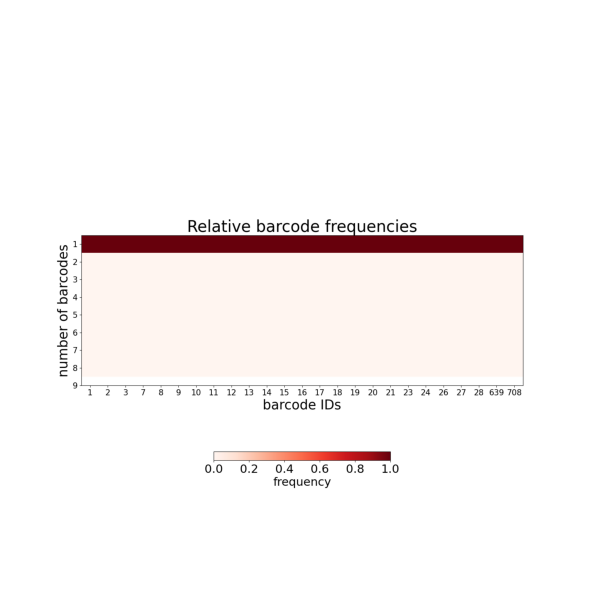

In [6]:
plot_file = f"{clean_path}/merged_traces_filtered_cleaned_relative_barcode_frequencies.png"
if os.path.exists(plot_file):
    print("▶ Barcode Repetition After Duplicate Filtering:")
    img = mpimg.imread(plot_file)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Plot not found at {plot_file}")

## Step 5: Visualize Trace Statistics After Cleaning

▶ Trace Statistics After Duplicate Filtering:


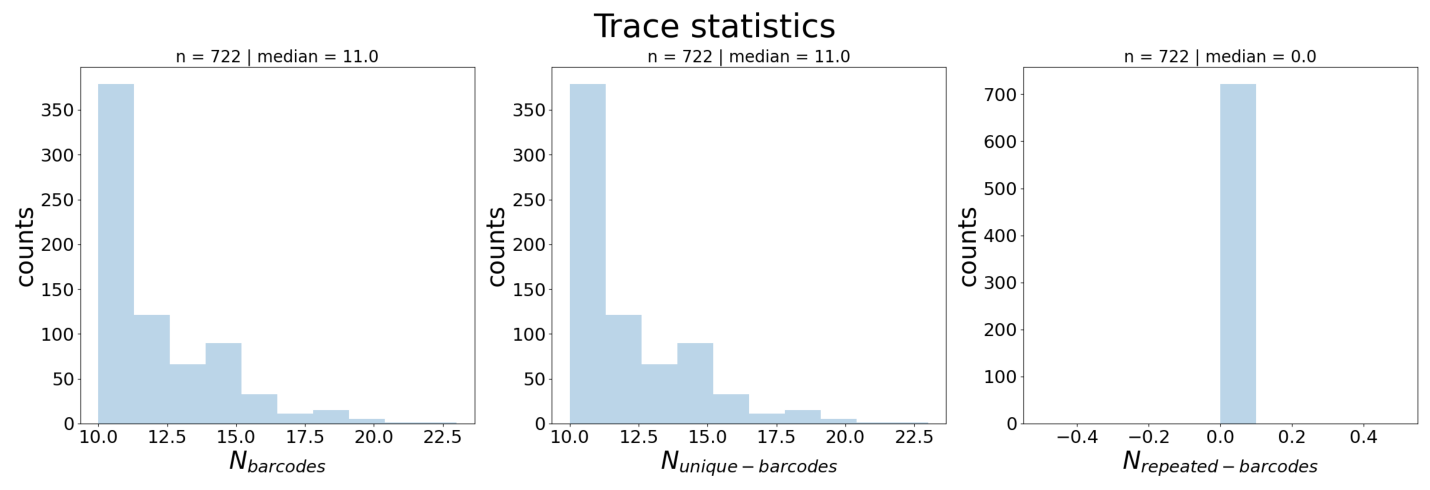

In [7]:
plot_file = f"{clean_path}/merged_traces_filtered_cleaned_trace_statistics.png"
if os.path.exists(plot_file):
    print("▶ Trace Statistics After Duplicate Filtering:")
    img = mpimg.imread(plot_file)
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Plot not found at {plot_file}")

## What --clean_spots Does

The `--clean_spots` flag removes:

1. **Duplicate UID spots**
   - Same Spot_ID detected multiple times
   - Typically from detector artifacts or data duplication

2. **Repeated barcodes**
   - Same barcode ID appearing multiple times in a single trace
   - Keeps only the FIRST occurrence (chronological order)
   - Other occurrences are removed

### Expected outcomes:
- **N_repeated_barcodes distribution** should drop to near zero (most traces have 0 repeated barcodes)
- **N_barcodes** will decrease slightly (duplicate spots removed)
- **Barcode repetition violins** should collapse to position 1.0 (each barcode appears once)

## Advanced: Intensity-Based Selection

For datasets with localization intensity information, a more sophisticated approach would select the **highest-intensity spot** when duplicates exist. This requires:

1. A localization file with intensity (peak) values
2. Custom script or workflow to:
   - Find all duplicates per barcode per trace
   - Rank by intensity
   - Keep only the highest-intensity spot

This is more scientifically principled since higher intensity = better localization precision.

**For this workflow**: Use intensity filtering in `trace_filter` (see Tutorial 3) rather than duplicate-specific handling.

## Reference: --clean_spots Options

### In trace_filter

| Option | Effect |
|--------|--------|
| `--clean_spots` | Remove duplicate UIDs AND repeated barcodes |

### Can combine with other filters

```bash
trace_filter --input traces.ecsv \
  --z_min 3.0 --z_max 11.0 \    # Spatial filtering
  --clean_spots \               # Remove duplicates
  --n_barcodes 10 \             # Min barcode count
  --output final
```

**Important:** `--n_barcodes` is applied LAST, after --clean_spots reduces trace length.

### Output filename format

- Input: `merged_traces_filtered.ecsv`
- With `--clean_spots --output cleaned`: `merged_traces_filtered_cleaned.ecsv`

## Interpreting Before/After Results

### Check N_repeated_barcodes histogram (from trace_statistics)

**Before cleaning:** Right histogram showing distribution across traces
- Peak may be at 2-5 (many traces have duplicates)
- Long tail toward higher values (some traces have many duplicates)

**After cleaning:** Should be mostly at zero
- Peak at 0 (no repeated barcodes)
- Median ≈ 0
- Few/no traces with repeated barcodes

### In barcode repetition plot (relative_barcode_frequencies)

**Before:** Violins spread out (some positions at 2, 3, 4+ occurrences)
**After:** All violins centered at 1.0 (each barcode appears once per trace)

## Summary

This tutorial demonstrated:

1. ✓ Removing duplicate spots with `--clean_spots`
2. ✓ Verifying impact on N_repeated_barcodes and barcode repetition patterns
3. ✓ Comparing QC metrics before/after cleaning

**Key Concepts:**
- `--clean_spots` removes both duplicate UIDs and repeated barcodes
- Keeps first occurrence of each barcode (SIMPLE/chronological approach)
- Always verify with QC: N_repeated_barcodes should drop to ~0
- Can combine with spatial/barcode filters in single trace_filter command

**Output:** Clean trace file without duplicate barcodes (`merged_traces_filtered_cleaned.ecsv`) ready for downstream analysis

**Next Tutorial:** Split large traces and identify individual molecules (tutorial_05_split_traces.ipynb)